# Phase 3: Regime A\n
\n
This notebook runs the first fixed-shape magnetization comparison for A.0, A.1, and A.2 using the cached NeuralMag vortex fixture from Phase 2.\n
\n
The goals are to:\n
- compare data-only, smoothness, and physics-coupled reconstructions\n
- report both observable and non-observable diagnostics\n
- run the shape-amplitude confound diagnostic\n

In [12]:
import numpy as np
import matplotlib.pyplot as plt
import jax
import jax.numpy as jnp
import unxt as u

from libertem_holo.base.mbir import (
    IdentityBackend,
    SmoothnessBackend,
    NeuralMagCritic,
    analytic_vortex_init,
    depth_correlation,
    forward_phase_from_density_and_magnetization,
    invert_magnetization,
    load_vortex_disc_fixture,
    mz_rmse,
    phase_residual,
    plot_depth_profile,
    plot_loss_history,
    plot_m_slices,
    projected_m_error,
    run_with_scaled_rho,
    support_center_yx,
    vortex_core_z_error,
)


def equilibrium_residual_local(m_recon, backend_alt, *, rho=None, support_threshold=1e-6):
    m_arr = jnp.asarray(m_recon)
    if rho is None:
        rho_arr = jnp.asarray(jnp.linalg.norm(m_arr, axis=-1) > support_threshold, dtype=m_arr.dtype)
    else:
        rho_arr = jnp.asarray(rho, dtype=m_arr.dtype)

    def total_energy(m_current):
        field = backend_alt.prepare(rho_arr, m_current)
        terms = backend_alt.energies(field)
        return jnp.sum(jnp.stack([jnp.asarray(value) for value in terms.values()]))

    grad_energy = jax.grad(total_energy)(m_arr)
    torque = jnp.cross(m_arr, grad_energy)
    return jnp.sqrt(jnp.mean(jnp.sum(torque ** 2, axis=-1)))


FIXTURE_SIZE = 32
MAX_ITER = 500
LEARNING_RATE = 5e-2
LAMBDA_SMOOTH = 1e-3
LAMBDA_PHYS = 1e-8
AXIS = 'z'

In [13]:
fixture = load_vortex_disc_fixture(FIXTURE_SIZE)
rho_true = np.asarray(fixture['rho_true'], dtype=np.float32)
m_true = np.asarray(fixture['m_true'], dtype=np.float32)
phi_true = np.asarray(fixture['phi_true'], dtype=np.float32)
pixel_size = u.Quantity(float(fixture['pixel_size_nm']), 'nm')
yx_center = support_center_yx(rho_true)

rho_true.shape, m_true.shape, phi_true.shape, pixel_size, yx_center

((32, 32, 32),
 (32, 32, 32, 3),
 (32, 32),
 Quantity(Array(5., dtype=float32, weak_type=True), unit='nm'),
 (16, 16))

In [14]:
def make_neuralmag_backend(rho, pixel_size_nm):
    import neuralmag as nm

    mesh = nm.Mesh(rho.shape, (pixel_size_nm * 1e-9,) * 3)
    state = nm.State(mesh)
    state.rho = nm.CellFunction(state, tensor=state.tensor(np.asarray(rho, dtype=np.float32)))
    state.material.Ms = nm.CellFunction(state).fill(8e5)
    state.material.A = nm.CellFunction(state).fill(1.3e-11)
    state.m = nm.VectorCellFunction(state, tensor=state.tensor(np.zeros(rho.shape + (3,), dtype=np.float32)))
    nm.ExchangeField().register(state, 'exchange')
    nm.DemagField(p=1).register(state, 'demag')
    return NeuralMagCritic.from_state(state, terms=('exchange', 'demag'))


def run_case(label, backend, lambda_phys, init='zero'):
    result = invert_magnetization(
        phi_true,
        rho_true,
        backend,
        pixel_size=pixel_size,
        lambda_phys=lambda_phys,
        max_iter=MAX_ITER,
        lr=LEARNING_RATE,
        init=init,
        axis=AXIS,
    )
    return {
        'label': label,
        'backend': backend,
        'result': result,
        'phase_residual': float(phase_residual(result.phi_pred, phi_true)),
        'projected_m_error': float(projected_m_error(result.m_recon, m_true)),
        'mz_rmse': float(mz_rmse(result.m_recon, m_true)),
        'depth_correlation': float(depth_correlation(result.m_recon, m_true, yx_center)),
        'vortex_core_z_error': float(vortex_core_z_error(result.m_recon, m_true, yx_center)),
        'equilibrium_residual': float(equilibrium_residual_local(result.m_recon, SmoothnessBackend(), rho=rho_true)),
    }


cases = [
    run_case('A.0', IdentityBackend(), 0.0),
    run_case('A.1', SmoothnessBackend(), LAMBDA_SMOOTH),
    run_case('A.2', make_neuralmag_backend(rho_true, float(pixel_size.value)), LAMBDA_PHYS),
]

summary_rows = [
    {k: v for k, v in case.items() if k not in {'backend', 'result'}}
    for case in cases
]
summary_rows

W0420 11:45:55.913174  656220 autotuner.cc:583] No reference output found even though buffer checking was requested while autotuning
/Users/landers/.conda/envs/holography_error/lib/python3.14/site-packages/jax/_src/numpy/array_methods.py:125: UserWarning: Explicitly requested dtype float64 requested in astype is not available, and will be truncated to dtype float32. To enable more dtypes, set the jax_enable_x64 configuration option or the JAX_ENABLE_X64 shell environment variable. See https://github.com/jax-ml/jax#current-gotchas for more.
  return lax_numpy.astype(self, dtype, copy=copy, device=device)
/Users/landers/LiberTEM-holo/src/libertem_holo/base/mbir/kernel.py:139: UserWarning: Explicitly requested dtype float64 requested in asarray is not available, and will be truncated to dtype float32. To enable more dtypes, set the jax_enable_x64 configuration option or the JAX_ENABLE_X64 shell environment variable. See https://github.com/jax-ml/jax#current-gotchas for more.
  coeff_val =

[{'label': 'A.0',
  'phase_residual': 0.12080290913581848,
  'projected_m_error': 0.9499197006225586,
  'mz_rmse': 0.6778732538223267,
  'depth_correlation': 0.0,
  'vortex_core_z_error': 13.0,
  'equilibrium_residual': 0.583232581615448},
 {'label': 'A.1',
  'phase_residual': 0.4412826597690582,
  'projected_m_error': 1.0425456762313843,
  'mz_rmse': 0.6778732538223267,
  'depth_correlation': 0.0,
  'vortex_core_z_error': 13.0,
  'equilibrium_residual': 0.07843950390815735},
 {'label': 'A.2',
  'phase_residual': 0.11884963512420654,
  'projected_m_error': 0.8434987664222717,
  'mz_rmse': 0.7528588771820068,
  'depth_correlation': -0.6707525253295898,
  'vortex_core_z_error': 3.0,
  'equilibrium_residual': 0.5536479949951172}]

In [15]:
try:
    import pandas as pd
    display(pd.DataFrame(summary_rows))
except ImportError:
    summary_rows

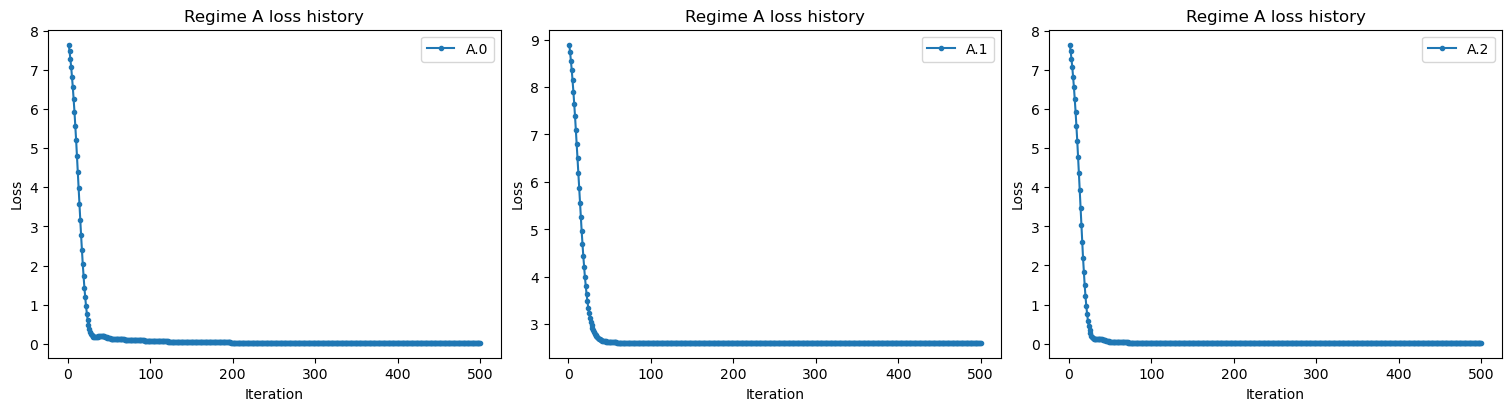

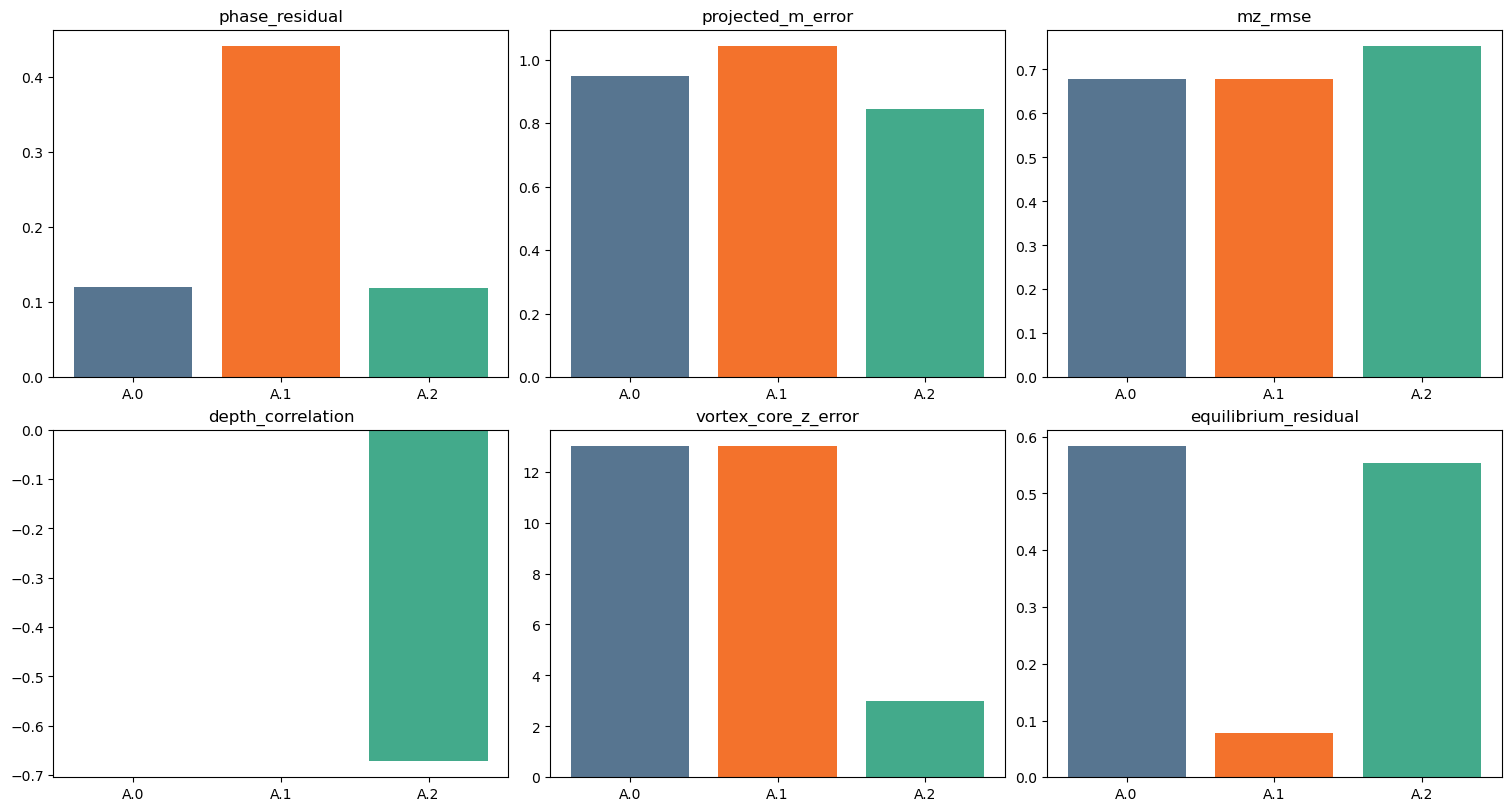

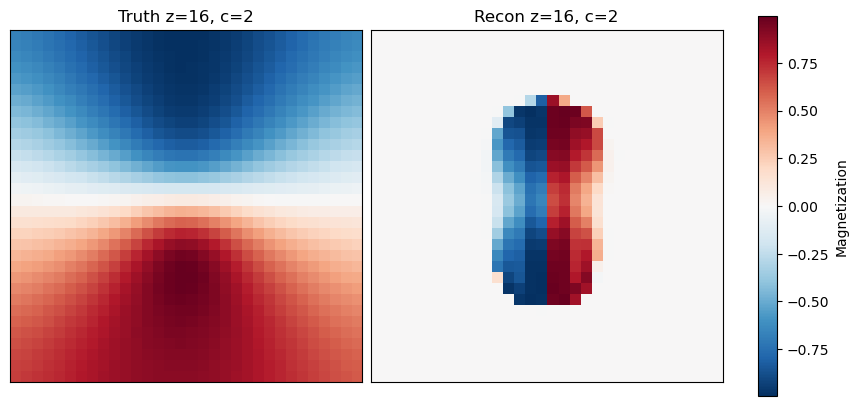

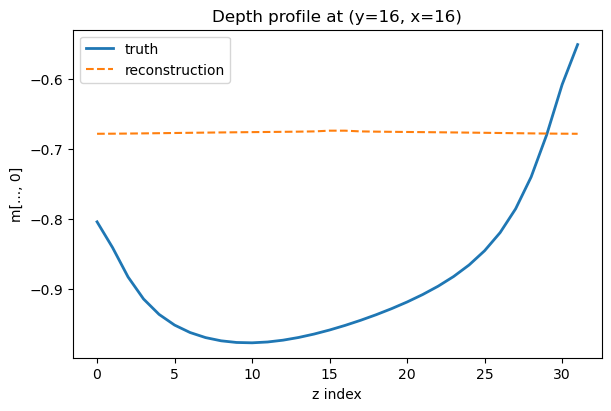

In [16]:
fig, axes = plt.subplots(1, len(cases), figsize=(5 * len(cases), 4), constrained_layout=True)
for ax, case in zip(np.atleast_1d(axes), cases):
    plot_loss_history(case['result'].loss_history, ax=ax, label=case['label'])
plt.show()

metric_names = [
    'phase_residual',
    'projected_m_error',
    'mz_rmse',
    'depth_correlation',
    'vortex_core_z_error',
    'equilibrium_residual',
]
labels = [row['label'] for row in summary_rows]
fig, axes = plt.subplots(2, 3, figsize=(15, 8), constrained_layout=True)
for ax, metric_name in zip(axes.ravel(), metric_names):
    values = [row[metric_name] for row in summary_rows]
    ax.bar(labels, values, color=['#577590', '#f3722c', '#43aa8b'])
    ax.set_title(metric_name)
    ax.set_xticks(range(len(labels)), labels)
plt.show()

fig, axes, _ = plot_m_slices(
    cases[-1]['result'].m_recon,
    m_true,
    z_index=rho_true.shape[0] // 2,
    component=2,
)
plt.show()

fig, ax, _ = plot_depth_profile(cases[-1]['result'].m_recon, m_true, yx_center, component=0)
plt.show()

/Users/landers/.conda/envs/holography_error/lib/python3.14/site-packages/jax/_src/numpy/array_methods.py:125: UserWarning: Explicitly requested dtype float64 requested in astype is not available, and will be truncated to dtype float32. To enable more dtypes, set the jax_enable_x64 configuration option or the JAX_ENABLE_X64 shell environment variable. See https://github.com/jax-ml/jax#current-gotchas for more.
  return lax_numpy.astype(self, dtype, copy=copy, device=device)
/Users/landers/LiberTEM-holo/src/libertem_holo/base/mbir/kernel.py:139: UserWarning: Explicitly requested dtype float64 requested in asarray is not available, and will be truncated to dtype float32. To enable more dtypes, set the jax_enable_x64 configuration option or the JAX_ENABLE_X64 shell environment variable. See https://github.com/jax-ml/jax#current-gotchas for more.
  coeff_val = jnp.asarray(coeff.value, dtype=dtype)
/Users/landers/LiberTEM-holo/src/libertem_holo/base/mbir/kernel.py:159: UserWarning: Explicitl

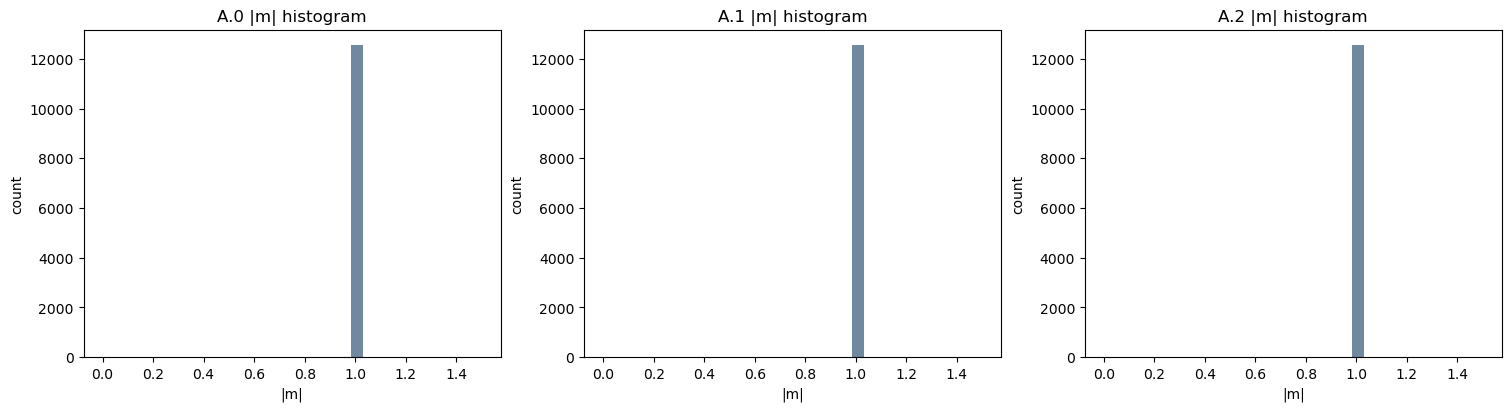

In [17]:
def rerun_case_with_scaled_rho(backend_factory, lambda_phys, init='zero'):
    def pipeline(phi_scaled, rho_scaled):
        backend = backend_factory(rho_scaled)
        return invert_magnetization(
            phi_scaled,
            rho_scaled,
            backend,
            pixel_size=pixel_size,
            lambda_phys=lambda_phys,
            max_iter=MAX_ITER,
            lr=LEARNING_RATE,
            init=init,
            axis=AXIS,
        )

    return pipeline


confound_runs = {
    'A.0': run_with_scaled_rho(
        rerun_case_with_scaled_rho(lambda rho: IdentityBackend(), 0.0),
        rho_true,
        m_true,
        pixel_size,
    ),
    'A.1': run_with_scaled_rho(
        rerun_case_with_scaled_rho(lambda rho: SmoothnessBackend(), LAMBDA_SMOOTH),
        rho_true,
        m_true,
        pixel_size,
    ),
    'A.2': run_with_scaled_rho(
        rerun_case_with_scaled_rho(
            lambda rho: make_neuralmag_backend(rho, float(pixel_size.value)),
            LAMBDA_PHYS,
        ),
        rho_true,
        m_true,
        pixel_size,
    ),
}

confound_summary = {
    label: run.mean_abs_m
    for label, run in confound_runs.items()
}
confound_summary

fig, axes = plt.subplots(1, len(confound_runs), figsize=(5 * len(confound_runs), 4), constrained_layout=True)
for ax, (label, run) in zip(np.atleast_1d(axes), confound_runs.items()):
    widths = np.diff(run.hist_edges)
    ax.bar(run.hist_edges[:-1], run.hist_counts, width=widths, align='edge', color='#577590', alpha=0.85)
    ax.set_title(f'{label} |m| histogram')
    ax.set_xlabel('|m|')
    ax.set_ylabel('count')
plt.show()

In [18]:
summary_rows, confound_summary

([{'label': 'A.0',
   'phase_residual': 0.12080290913581848,
   'projected_m_error': 0.9499197006225586,
   'mz_rmse': 0.6778732538223267,
   'depth_correlation': 0.0,
   'vortex_core_z_error': 13.0,
   'equilibrium_residual': 0.583232581615448},
  {'label': 'A.1',
   'phase_residual': 0.4412826597690582,
   'projected_m_error': 1.0425456762313843,
   'mz_rmse': 0.6778732538223267,
   'depth_correlation': 0.0,
   'vortex_core_z_error': 13.0,
   'equilibrium_residual': 0.07843950390815735},
  {'label': 'A.2',
   'phase_residual': 0.11884963512420654,
   'projected_m_error': 0.8434987664222717,
   'mz_rmse': 0.7528588771820068,
   'depth_correlation': -0.6707525253295898,
   'vortex_core_z_error': 3.0,
   'equilibrium_residual': 0.5536479949951172}],
 {'A.0': 1.0, 'A.1': 1.0, 'A.2': 1.0})

## Interpretation

Current Regime A result on the cached `32^3` vortex fixture:

- `A.2` matches `A.0` on phase residual (`~0.119` vs `~0.121`) and improves projected magnetization error (`~0.843` vs `~0.950`, `A.1 ~1.043`).
- On non-observable structure, `A.2` is mixed rather than uniformly better: it improves vortex-core z error strongly (`3` vs `13` for `A.0/A.1`), but `M_z` RMSE is worse (`~0.753` vs `~0.678`) and the depth-profile correlation is negative (`~-0.67`).
- `A.1` minimizes the smoothness-based equilibrium proxy because the proxy backend overlaps with the smoothness prior. That makes it a useful sanity check, but not independent evidence that `A.1` reconstructs the correct 3D state.
- The current shape-amplitude confound run is not discriminative: all three reconstructions collapse to `|m| ≈ 1` histograms under the hard unit-norm projection, so this diagnostic needs to be reformulated if it is meant to separate `A.2` from `A.0/A.1`.

Provisional takeaway: the physics-coupled critic is already helping on some 3D structure metrics, especially vortex-core depth localization, but the current objective and tuning do not yet improve the full non-observable magnetization state. The next iteration should focus on metric-independent equilibrium diagnostics, initialization and `lambda_phys` sweeps, and then the electrostatic `A.2e` extension.

`A.2e` is not included in this notebook yet; that still requires the electrostatic forward term and joint `m + V_0` optimization path.